# BioSED: Detección de Eventos Sonoros en Aves (CRNN)

Este notebook contiene el flujo completo para entrenar un modelo BioSED (Bioacoustic Sound Event Detection) utilizando PyTorch. Nuestro objetivo es entrenar un modelo que pueda predecir en qué momento (frame a frame) canta cada una de las 10 especies.

### Celda 0: Cargar los datos y etiquetado con modelo de Cornell

Se traen los datos desde la página web xeno-canto utilizando la API de la página y se le añaden las etiquetas temporales a cada audio 

In [13]:
import os
import requests
import time
import urllib.parse
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio

# 1. Asegúrate de que el API Key esté entre comillas para que no genere un error de sintaxis en Python
key = "f803b7018e2a9638e0c9c50998f681bcb1b1042f"

def descargar_de_xeno_canto(especie_nombre, max_archivos=5, base_dir="dataset_aves"):
    """
    Busca una especie en la API de Xeno-Canto v3 (filtrando por audios de Colombia) 
    y descarga los archivos de forma organizada.
    """
    carpeta_especie = os.path.join(base_dir, especie_nombre.replace(" ", "_"))
    os.makedirs(carpeta_especie, exist_ok=True)
    
    print(f"\nBuscando: {especie_nombre} ...")
    
    # 2. La query sigue siendo la misma
    query = f'sp:"{especie_nombre}"+cnt:colombia'
    query_encoded = urllib.parse.quote(query)
    
    # 3. La API ahora es la versión 3 y el parámetro 'key' se envía como un parámetro extra (&key=)
    url = f"https://xeno-canto.org/api/3/recordings?query={query}&key={key}"
    
    try:
        respuesta = requests.get(url, timeout=10)
        respuesta.raise_for_status()
    except requests.exceptions.HTTPError as errUrl:
        print(f"Error de acceso (HTTPError): {errUrl}")
        return
    except Exception as e:
        print(f"Error conectando a la API: {e}")
        return

    datos = respuesta.json()
    grabaciones = datos.get('recordings', [])
    cant_disponible = len(grabaciones)
    descargas = min(max_archivos, cant_disponible)
    
    if descargas == 0:
        print("  - No se encontraron audios.")
        return
        
    print(f"  - Encontrados {cant_disponible} audios. Descargando {descargas}...")
    
    guardados_exito = 0
    for grabacion in grabaciones[:descargas]:
        audio_url = grabacion.get('file')
        if not audio_url: 
            continue
            
        ruta_archivo = os.path.join(carpeta_especie, f"{grabacion['id']}.mp3")
        
        # Evitar re-descargar si el audio ya existe
        if not os.path.exists(ruta_archivo):
            try:
                res_audio = requests.get(audio_url, timeout=20)
                if res_audio.status_code == 200:
                    with open(ruta_archivo, 'wb') as f:
                        f.write(res_audio.content)
                    guardados_exito += 1
                time.sleep(1) # Pausa amigable para no bloquear nuestro IP
            except Exception as e:
                print(f"  - Error descargando ID {grabacion['id']}: {e}")
        else:
            guardados_exito += 1  # Ya estaba descargado
            
    print(f"  - Completado: {guardados_exito}/{descargas} archivos guardados en '{carpeta_especie}'.")

# =====================================================================
# 10 Especies muy comunes y emblemáticas que se encuentran en Medellín
# (Valle de Aburrá, Colombia)
# =====================================================================
especies_medellin = [
    "Turdus ignobilis",        # Mirla / Black-billed Thrush (Canto constante en las mañanas)
    "Pitangus sulphuratus",    # Bichofué (Llamado inconfundible 'Bicho-fue')
    "Thraupis episcopus",      # Azulejo común
    "Zonotrichia capensis",    # Copetón
    "Tyrannus melancholicus",  # Sirirí (Ave que defiende su territorio agresivamente)
    "Pygochelidon cyanoleuca", # Golondrina barranquera
    "Troglodytes aedon",       # Cucarachero (Canto muy melodioso y fuerte)
    "Crotophaga ani",          # Garrapatero
    "Thraupis palmarum",       # Azulejo palmero
    "Campylorhynchus griseus"  # Cucarachero chupahuevo / Bicolored Wren
]

# Puedes ejecutar este ciclo (quitándole los comentarios) para iniciar la descarga:
print(f"Iniciando descarga del dataset para {len(especies_medellin)} especies de Medellín...")
for especie in especies_medellin:
    descargar_de_xeno_canto(especie, max_archivos=50, base_dir="dataset_aves")
print("\n¡Descarga finalizada!")

Iniciando descarga del dataset para 10 especies de Medellín...

Buscando: Turdus ignobilis ...
  - Encontrados 62 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Turdus_ignobilis'.

Buscando: Pitangus sulphuratus ...
  - Encontrados 100 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Pitangus_sulphuratus'.

Buscando: Thraupis episcopus ...
  - Encontrados 71 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Thraupis_episcopus'.

Buscando: Zonotrichia capensis ...
  - Encontrados 100 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Zonotrichia_capensis'.

Buscando: Tyrannus melancholicus ...
  - Encontrados 86 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Tyrannus_melancholicus'.

Buscando: Pygochelidon cyanoleuca ...
  - Encontrados 33 audios. Descargando 33...
  - Completado: 33/33 archivos guardados en 'data

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

# 1. Inicializar el analizador de BirdNET (descarga el modelo automáticamente)
print("Cargando modelo de BirdNET...")
analyzer = Analyzer()

# 2. Configurar las rutas de tus datos
DATA_DIR = "dataset_aves"  # Cambia esto por tu ruta real
resultados = []

# 3. Recorrer las carpetas de las 10 especies
especies_carpetas = [f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))]

print("Iniciando el procesamiento de audios...")
for especie_carpeta in especies_carpetas:
    ruta_carpeta = os.path.join(DATA_DIR, especie_carpeta)
    archivos_audio = [f for f in os.listdir(ruta_carpeta) if f.endswith(('.wav', '.mp3', '.flac'))]
    
    print(f"\nProcesando especie: {especie_carpeta} ({len(archivos_audio)} archivos)")
    
    for archivo in tqdm(archivos_audio):
        ruta_audio = os.path.join(ruta_carpeta, archivo)
        
        try:
            # 4. Pasar el audio a BirdNET
            # min_conf=0.10 para capturar cantos tenues; luego podemos filtrar más estricto
            recording = Recording(analyzer, ruta_audio, min_conf=0.10)
            recording.analyze()
            
            # 5. Extraer las detecciones encontradas en el audio
            for deteccion in recording.detections:
                resultados.append({
                    "archivo_original": archivo,
                    "especie_carpeta": especie_carpeta,  # La etiqueta que tú le diste originalmente
                    "ave_detectada_comun": deteccion["common_name"],
                    "ave_detectada_cientifico": deteccion["scientific_name"],
                    "inicio_segundo": deteccion["start_time"],
                    "fin_segundo": deteccion["end_time"],
                    "confianza_birdnet": deteccion["confidence"]
                })
                
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")

# 6. Convertir a un DataFrame de Pandas
df_etiquetas_fuertes = pd.DataFrame(resultados)
print(f"\n¡Proceso completado! Se encontraron {len(df_etiquetas_fuertes)} segmentos de canto.")

In [ ]:
output_path = os.path.join(DATA_DIR, "df_etiquetas_fuertes.csv")
df_etiquetas_fuertes.to_csv(output_path, index=False)
print(f"Guardado CSV: {output_path}")

### Celda 1: Setup y Librerías
Importación de las librerías necesarias para procesamiento de audio, redes neuronales y evaluación. También configuramos la semilla para reproducibilidad.

In [ ]:


# Configurar determinismo para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo: {device}")

Dispositivo activo: cpu


### Celda 2: Funciones de Preprocesamiento
Función para extraer los Log-Mel Spectrograms, que son el estándar de entrada visual-auditiva para arquitecturas CRNN.

In [2]:
# Celda 2: Audio Preprocessing Function
def extract_log_mel_spectrogram(file_path, sr=32000, n_mels=64, n_fft=1024, hop_length=512):
    """
    Carga un archivo de audio (.mp3, .wav), lo remuestrea si es necesario y obtiene
    su Log-Mel Spectrogram.
    """
    try:
        waveform, sample_rate = torchaudio.load(file_path)
    except Exception as e:
        print(f"Error cargando {file_path}: {e}")
        return None
    
    # Promediar a un solo canal (mono) si el archivo es estéreo
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
        
    # Remuestrear si el rate origin no concuerda
    if sample_rate != sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=sr)
        waveform = resampler(waveform)

    # Transformación a Mel Spectrogram
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_spec = mel_transform(waveform)
    
    # Conversión a escala logarítmica (Decibelios)
    log_mel_spec = torchaudio.transforms.AmplitudeToDB()(mel_spec)
    
    # Quitar la dimensión del canal y Transponer para que quede [Frames, n_mels]
    log_mel_spec = log_mel_spec.squeeze(0).transpose(0, 1) 
    
    return log_mel_spec

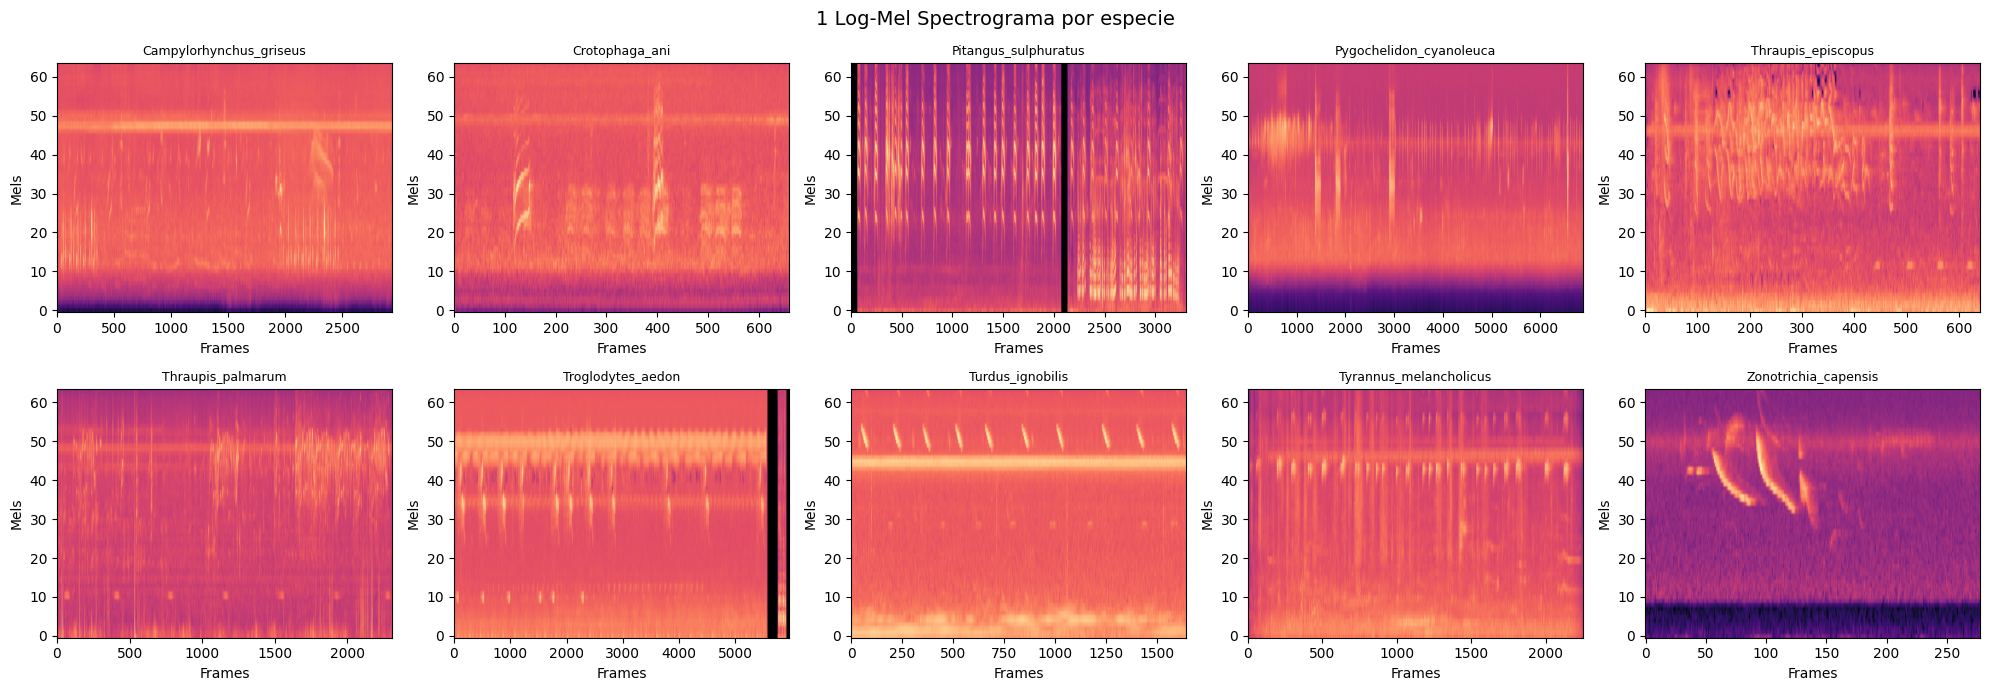

### Celda 3: Dataset Personalizado y DataLoader
Manejo de etiquetas temporales. Como los audios duran 10s, si usamos una ventana `hop_length` de 512, vamos a generar una rejilla de frames de tiempo. Aquí interpolamos los `inicio_segundo` y `fin_segundo` para encajar los "unos" (1.0) en la matriz de etiquetas de los instantes activos.

In [3]:
# Celda 3: Custom Dataset and DataLoader
class BioSEDDataset(Dataset):
    def __init__(self, file_paths, df_labels, class_to_idx, sr=32000, duration=10, hop_length=512, n_mels=64):
        self.file_paths = file_paths
        self.df_labels = df_labels
        self.class_to_idx = class_to_idx
        self.sr = sr
        self.hop_length = hop_length
        self.n_mels = n_mels
        
        # Calcular el número de frames objetivo temporalmente
        self.num_frames = int((sr * duration) / hop_length) + 1
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        filename = os.path.basename(file_path)
        
        # Matriz objetivo de la forma: [Frames, Num_Clases]
        target_matrix = torch.zeros((self.num_frames, len(self.class_to_idx)))
        
        # Filtrar las etiquetas de este audio
        file_labels = self.df_labels[self.df_labels['archivo_original'] == filename]
        
        for _, row in file_labels.iterrows():
            especie = row['especie_carpeta']
            if especie in self.class_to_idx:
                c_idx = self.class_to_idx[especie]
                # Convertir los tiempos a índices del frame
                start_frame = int((row['inicio_segundo'] * self.sr) / self.hop_length)
                end_frame = int((row['fin_segundo'] * self.sr) / self.hop_length)
                
                # Asignar probabilidad 1 a los frames que conforman evento de canto
                # Protegemos contra desbordamientos fuera de (0, num_frames - 1)
                start_frame = max(0, min(start_frame, self.num_frames - 1))
                end_frame = max(0, min(end_frame, self.num_frames - 1))
                target_matrix[start_frame:end_frame+1, c_idx] = 1.0
                
        # Extraer log-Mel
        features = extract_log_mel_spectrogram(file_path, sr=self.sr, hop_length=self.hop_length, n_mels=self.n_mels)
        if features is None:
            features = torch.zeros((self.num_frames, self.n_mels))
        
        # Ajustar para garantizar mismo largo de frame en todos los batch (Padding / Truncado)
        if features.shape[0] < self.num_frames:
            padding = torch.zeros((self.num_frames - features.shape[0], features.shape[1]))
            features = torch.cat((features, padding), dim=0)
        else:
            features = features[:self.num_frames, :]
            
        # Para que PyTorch interprete esto como imagen 2D damos forma (Canal, Frames, Mels)
        features = features.unsqueeze(0)
        
        return features, target_matrix

# ---> Lógica de Separación y Datasets <---

# Cargar CSV
df = pd.read_csv('dataset_aves/df_etiquetas_fuertes.csv')

# Crear diccionario clasificador 
clases = sorted(df['especie_carpeta'].unique())
class_to_idx = {c: i for i, c in enumerate(clases)}
print(f"Clases a predecir ({len(clases)}):", list(class_to_idx.keys()))

# Obtener archivos
directorios = 'dataset_aves'
todos_los_archivos = []
for root, _, files in os.walk(directorios):
    for f in files:
        if f.endswith('.mp3'):
            todos_los_archivos.append(os.path.join(root, f))

# Splits (Aprovechamos que los audios provienen de distintas especies para estratificar si es posible, 
# aunque es simpler y robusto separar por archivo)
train_files, test_files = train_test_split(todos_los_archivos, test_size=0.30, random_state=SEED)
val_files, test_files = train_test_split(test_files, test_size=0.50, random_state=SEED) # 15% Val, 15% Test

# Creación de Loads
train_ds = BioSEDDataset(train_files, df, class_to_idx)
val_ds = BioSEDDataset(val_files, df, class_to_idx)
test_ds = BioSEDDataset(test_files, df, class_to_idx)

# DataLoaders configurados
batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Archivos: Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")

Clases a predecir (10): ['Campylorhynchus_griseus', 'Crotophaga_ani', 'Pitangus_sulphuratus', 'Pygochelidon_cyanoleuca', 'Thraupis_episcopus', 'Thraupis_palmarum', 'Troglodytes_aedon', 'Turdus_ignobilis', 'Tyrannus_melancholicus', 'Zonotrichia_capensis']
Archivos: Train=334 | Val=72 | Test=72


### Celda 4: Arquitectura del modelo CRNN
En un detector SED de biacústica, la CNN extrae características visuales locales. Al final de la CNN usamos `mean` en la dimensión de frecuencia para colapsarla y enviar la secuencia rastreada al Bi-GRU (para capturar contexto hacia adelante y atrás temporalmente).

In [4]:
# Celda 4: CRNN Model Architecture
class CRNN_BioSED(nn.Module):
    def __init__(self, num_classes=10):
        super(CRNN_BioSED, self).__init__()
        
        # Bloque CNN para extraer features de los Spectrogramas (Imágenes)
        # Entrada: [Batch, Canal=1, Frames, Mels]
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)),  # Solo reducimos dimensión frecuencial, no los frames
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2))
        )
        
        # Tras MaxPool secuenciales, el eje de Mels se reduce.
        # Si empezamos con Mels=64: 64 -> 32 -> 16 -> 8
        self.gru = nn.GRU(input_size=128 * 8, hidden_size=128, num_layers=2, 
                          batch_first=True, bidirectional=True, dropout=0.2)
        
        # Capa Lineal Clasificadora (Output Head)
        self.fc = nn.Linear(in_features=128 * 2, out_features=num_classes)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: [Batch, 1, Frames, Mels]
        # 1. Pisar por los bloques convolucionales
        x = self.conv_block(x)         # Shape: [Batch, 128, Frames, Mels/8]
        
        # 2. Reshape para el GRU (Queremos: [Batch, Frames, Canales * Mels_restantes])
        batch, c, frames, m = x.shape
        x = x.permute(0, 2, 1, 3)      # Mover ejes: [Batch, Frames, 128, Mels/8]
        x = x.reshape(batch, frames, c * m) # Flatten features: [Batch, Frames, Features]
        
        # 3. Componente Temporal (Bi-GRU)
        x, _ = self.gru(x)             # Shape: [Batch, Frames, 128 * 2 direcciones]
        
        # 4. Clasificación Multi-Etiqueta Independiente para cada frame
        x = self.fc(x)                 # Shape: [Batch, Frames, Num_Classes]
        y_prob = self.sigmoid(x)       # Probabilidades entre 0.0 y 1.0
        
        return y_prob

# Instanciar modelo
model = CRNN_BioSED(num_classes=len(clases)).to(device)
print(model)

CRNN_BioSED(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1

### Celda 5: Loop de Entrenamiento y Pérdida
El problema es multi-label classification en el tiempo. Usaremos BCE (Binary Cross Entropy).

Error cargando dataset_aves\Troglodytes_aedon\773325.mp3: Failed to decode audio samples: decodeAVFrame, C:\actions-runner\_work\torchcodec\torchcodec\meta-pytorch\torchcodec\src\torchcodec\_core\SingleStreamDecoder.cpp:1498, Could not push packet to decoder: Invalid data found when processing input
Error cargando dataset_aves\Turdus_ignobilis\433294.mp3: Failed to decode audio samples: decodeAVFrame, C:\actions-runner\_work\torchcodec\torchcodec\meta-pytorch\torchcodec\src\torchcodec\_core\SingleStreamDecoder.cpp:1498, Could not push packet to decoder: Invalid data found when processing input
Error cargando dataset_aves\Turdus_ignobilis\425787.mp3: Failed to decode audio samples: decodeAVFrame, C:\actions-runner\_work\torchcodec\torchcodec\meta-pytorch\torchcodec\src\torchcodec\_core\SingleStreamDecoder.cpp:1498, Could not push packet to decoder: Invalid data found when processing input
Epoch [1/15] -> Train Loss: 0.3069 | Val Loss: 0.2558
Error cargando dataset_aves\Turdus_ignobilis\

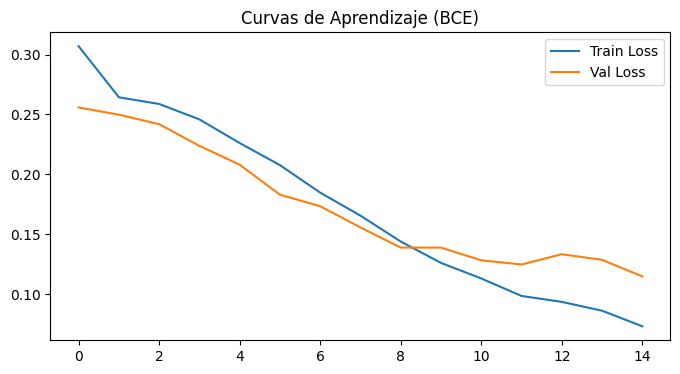

In [5]:
# Celda 5: Loss Function and Training Loop
num_epochs = 15 # Aumentar para mejor convergencia en prod
criterion = nn.BCELoss() # Puesto que ya hemos pasado el output por Sigmoid
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device) # Shape: [Batch, Frames, Clases]
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    if (epoch+1) % 3 == 0 or epoch == 0:
        print(f"Epoch [{(epoch+1)}/{num_epochs}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# Plotear la curva de pérdida
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de Aprendizaje (BCE)')
plt.legend()
plt.show()

### Celda 6: Post-Procesamiento y Filtro de Umbral (Threshold)
Dado que el modelo escupe eventos por frame, los agrupas e interpretas los frames continuos como un segmento (inicio_segundo y fin_segundo).

In [6]:
# Celda 6: Post-Processing and Thresholding
def get_predicted_events(probs_matrix, species_dict, threshold=0.5, sr=32000, hop_length=512):
    """
    Toma un array crudo 2D [Frames, Clases] y retorna lista de predicciones en dict:
    [{'start': 3.1, 'end': 3.8, 'species': 'T. aedon'}, ...]
    """
    events = []
    idx_to_class = {i: c for c, i in species_dict.items()}
    
    # Matriz booleana de activaciones
    binarized = (probs_matrix > threshold).astype(int)
    
    # Interar a través de cada clase
    frames = binarized.shape[0]
    num_classes = binarized.shape[1]
    
    for c_idx in range(num_classes):
        in_event = False
        start_frame, end_frame = 0, 0
        
        for f in range(frames):
            if binarized[f, c_idx] == 1 and not in_event:
                in_event = True
                start_frame = f
            elif binarized[f, c_idx] == 0 and in_event:
                in_event = False
                end_frame = f
                
                # Transformamos frames a segundos
                start_sec = (start_frame * hop_length) / sr
                end_sec = (end_frame * hop_length) / sr
                
                # Solo guardamos eventos consistentes (>0.2s)
                if (end_sec - start_sec) > 0.2:
                    events.append({
                        'start': round(start_sec, 2),
                        'end': round(end_sec, 2),
                        'species': idx_to_class[c_idx]
                    })
                    
        # Para eventos que tocan el final 
        if in_event:
            end_sec = (frames * hop_length) / sr
            events.append({
                'start': round((start_frame * hop_length) / sr, 2),
                'end': round(end_sec, 2),
                'species': idx_to_class[c_idx]
            })
            
    return events

### Celda 7: Evaluación (mAP)
Test final, recopila todos los frames y usa métricas de AP global para computar si la red aprendió a segmentar (clasificación de píxeles/frames).

--------- Métricas de Frame-Level AP ---------
AP para Campylorhynchus_griseus: 0.6633
AP para Crotophaga_ani: 0.5986
AP para Pitangus_sulphuratus: 0.9475
AP para Pygochelidon_cyanoleuca: 0.4820
AP para Thraupis_episcopus: 0.7965
AP para Thraupis_palmarum: 0.0815
AP para Troglodytes_aedon: 0.5145
AP para Turdus_ignobilis: 0.6070
AP para Tyrannus_melancholicus: 0.5758
AP para Zonotrichia_capensis: 0.8453
Mean Average Precision (mAP) -> 0.6112


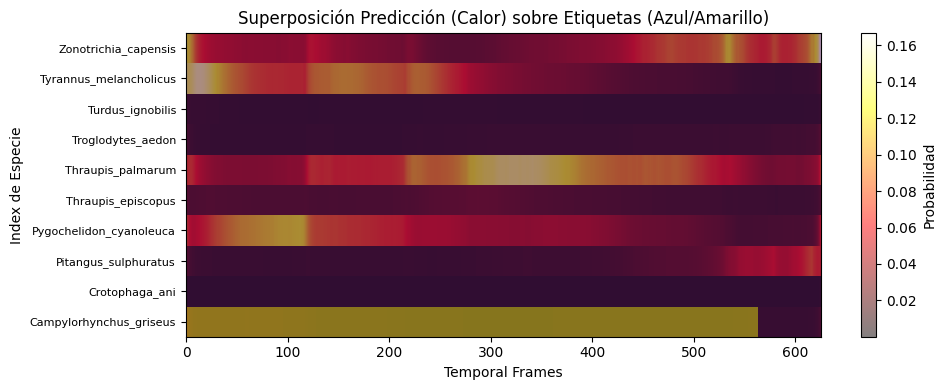

In [7]:
# Celda 7: Evaluation Framework (mAP)
model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.cpu().numpy()
        
        # Predicción del CRNN
        outputs = model(inputs).cpu().numpy()
        
        all_targets.append(targets)
        all_predictions.append(outputs)
        
# Aplanar y reordenar todo en formas: [Total_Frames_Todo_Test, Num_Clases]
all_targets = np.concatenate(all_targets, axis=0).reshape(-1, len(clases))
all_predictions = np.concatenate(all_predictions, axis=0).reshape(-1, len(clases))

average_precisions = []

# Calcular Average Precision especie por especie
print("--------- Métricas de Frame-Level AP ---------")
for i, clase in enumerate(clases):
    # Evita el cálculo si no hubo ejemplos base de una clase en el chunk de Test
    if np.sum(all_targets[:, i]) > 0:
        ap = average_precision_score(all_targets[:, i], all_predictions[:, i])
        average_precisions.append(ap)
        print(f"AP para {clase}: {ap:.4f}")
    else:
        print(f"AP para {clase}: N/A (Test sin Data)")

mAP = np.mean(average_precisions)
print(f"=====================================")
print(f"Mean Average Precision (mAP) -> {mAP:.4f}")
print(f"=====================================")

# ---------- Plot de Diagnóstico Rápido ---------- #
import random
# Escogemos un archivo de test al azar para ver sus predicciones cronológicas
test_idx = random.randint(0, len(test_ds)-1)
sample_x, sample_y = test_ds[test_idx]
with torch.no_grad():
    sample_out = model(sample_x.unsqueeze(0).to(device)).cpu()[0].numpy()

plt.figure(figsize=(10, 4))
plt.imshow(sample_y.numpy().T, aspect='auto', interpolation='nearest', alpha=0.9, origin='lower')
plt.imshow(sample_out.T, aspect='auto', interpolation='nearest', alpha=0.5, origin='lower', cmap='hot')
plt.title(f"Superposición Predicción (Calor) sobre Etiquetas (Azul/Amarillo)")
plt.xlabel("Temporal Frames")
plt.ylabel("Index de Especie")
plt.yticks(ticks=range(len(clases)), labels=list(class_to_idx.keys()), fontsize=8)
plt.colorbar(label="Probabilidad")
plt.tight_layout()
plt.show()

In [8]:
# Guardar parámetros del modelo + metadatos útiles para inferencia
os.makedirs("artifacts", exist_ok=True)
checkpoint_path = "artifacts/biosed_crnn_checkpoint.pth"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "clases": clases,
    "seed": SEED,
    "audio_config": {
        "sr": 32000,
        "hop_length": 512,
        "n_mels": 64,
        "threshold_default": 0.5
    }
}

torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint guardado en: {checkpoint_path}")


def load_biosed_pipeline(ckpt_path, run_device=device):
    """Carga modelo entrenado y metadatos desde checkpoint."""
    ckpt = torch.load(ckpt_path, map_location=run_device)

    loaded_model = CRNN_BioSED(num_classes=len(ckpt["clases"])).to(run_device)
    loaded_model.load_state_dict(ckpt["model_state_dict"])
    loaded_model.eval()

    return loaded_model, ckpt


def run_biosed_inference(
    audio_path,
    loaded_model,
    species_dict,
    threshold=0.5,
    sr=32000,
    hop_length=512,
    n_mels=64,
    run_device=device
):
    """
    Pipeline de inferencia:
    1) extraer log-mel
    2) forward del modelo
    3) post-procesar a eventos [start, end, species]
    """
    features = extract_log_mel_spectrogram(
        audio_path, sr=sr, hop_length=hop_length, n_mels=n_mels
    )
    if features is None:
        return None, []

    # [Frames, Mels] -> [Batch=1, Canal=1, Frames, Mels]
    x = features.unsqueeze(0).unsqueeze(0).to(run_device)

    with torch.no_grad():
        probs = loaded_model(x)[0].cpu().numpy()  # [Frames, Clases]

    events = get_predicted_events(
        probs, species_dict, threshold=threshold, sr=sr, hop_length=hop_length
    )
    return probs, events


# =========================================================
# Pipeline comentado para usar luego:
# =========================================================
# infer_model, meta = load_biosed_pipeline("artifacts/biosed_crnn_checkpoint.pth")
#
# audio_file = "dataset_aves/Zonotrichia_capensis/985616.mp3"
# probs_matrix, predicted_events = run_biosed_inference(
#     audio_path=audio_file,
#     loaded_model=infer_model,
#     species_dict=meta["class_to_idx"],
#     threshold=meta["audio_config"]["threshold_default"],
#     sr=meta["audio_config"]["sr"],
#     hop_length=meta["audio_config"]["hop_length"],
#     n_mels=meta["audio_config"]["n_mels"]
# )
#
# print(f"Número de eventos detectados: {len(predicted_events)}")
# print(predicted_events[:5])

Checkpoint guardado en: artifacts/biosed_crnn_checkpoint.pth


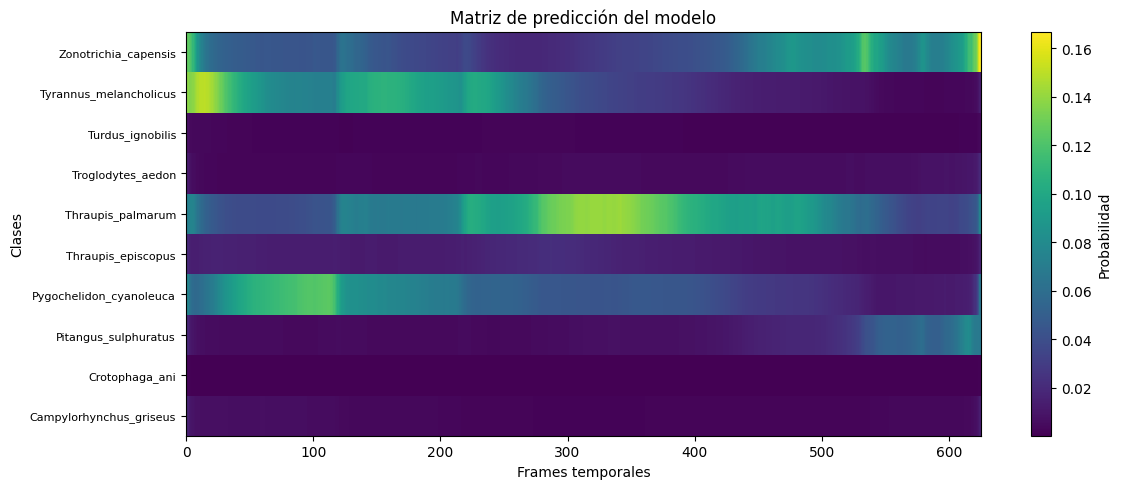

In [9]:
plt.figure(figsize=(12, 5))
plt.imshow(sample_out.T, aspect='auto', origin='lower', interpolation='nearest', cmap='viridis')
plt.colorbar(label='Probabilidad')
plt.title('Matriz de predicción del modelo')
plt.xlabel('Frames temporales')
plt.ylabel('Clases')

plt.yticks(
    ticks=range(len(clases)),
    labels=clases,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [ ]:
# Plot de 1 Log-Mel spectrograma por especie
n_cols = 5
n_rows = int(np.ceil(len(clases) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7))
axes = axes.flatten()

for i, especie in enumerate(clases):
    ax = axes[i]
    species_dir = os.path.join(directorios, especie)

    if not os.path.isdir(species_dir):
        ax.set_title(especie, fontsize=9)
        ax.text(0.5, 0.5, "Carpeta no encontrada", ha="center", va="center")
        ax.axis("off")
        continue

    archivos_mp3 = sorted([f for f in os.listdir(species_dir) if f.endswith(".mp3")])
    if len(archivos_mp3) == 0:
        ax.set_title(especie, fontsize=9)
        ax.text(0.5, 0.5, "Sin .mp3", ha="center", va="center")
        ax.axis("off")
        continue

    file_path = os.path.join(species_dir, archivos_mp3[2])
    mel = extract_log_mel_spectrogram(file_path)

    if mel is None:
        ax.set_title(especie, fontsize=9)
        ax.text(0.5, 0.5, "Error al cargar audio", ha="center", va="center")
        ax.axis("off")
        continue

    im = ax.imshow(mel.T.numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(especie, fontsize=9)
    ax.set_xlabel("Frames")
    ax.set_ylabel("Mels")

# Ocultar ejes sobrantes si aplica
for j in range(len(clases), len(axes)):
    axes[j].axis("off")

fig.suptitle("1 Log-Mel Spectrograma por especie", fontsize=14)
plt.tight_layout()
plt.show()